# Deep Learning for Time-Series Forecasting

**Aim:** To apply a deep learning model (Neural Network) to forecast the `daily_vaccinations_per_million` for a country.

**Model:** `MLPRegressor` (Multi-layer Perceptron) from scikit-learn.

**Methodology:**
1.  We will use the cleaned vaccinations dataset.
2.  We will select a single country ('Germany') for a focused time-series analysis.
3.  We will create "lag features" (using the past 30 days) to predict the next day.
4.  The data will be scaled, as neural networks require this.
5.  We will train the model and visualize its predictions against the actual data.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)

# Data Loading and Preparation

In [3]:
df = pd.read_csv("vaccinations_cleaned.csv")

In [4]:
# Convert date and filter for our target country
df['date'] = pd.to_datetime(df['date'])
country = 'Germany'
country_df = df[df['location'] == country].copy()
country_df = country_df.sort_values(by='date')

In [5]:
# Select the feature we want to forecast
dataset = country_df['daily_vaccinations_per_million'].values
dataset = dataset.reshape(-1, 1) # Reshape for the scaler

In [6]:
# Scale the data (LSTMs and MLPs work best with scaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# Feature Engineering: Create Time-Series Sequences

This function converts our time series into a supervised learning problem.

X = [data at t-30, ..., data at t-1], y = [data at t]

In [7]:
def create_sequences(data, look_back=30):
    X, y = [], []
    for i in range(len(data) - look_back - 1):
        a = data[i:(i + look_back), 0]
        X.append(a)
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

In [8]:
# We will use the last 30 days to predict the next day
look_back = 30
X, y = create_sequences(dataset_scaled, look_back)

In [9]:
# Split into training and test sets (we'll use 80% for training)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [10]:
print(f"Created {len(X_train)} training samples and {len(X_test)} testing samples.")
print(f"Shape of X_train: {X_train.shape} (Each sample has {X_train.shape[1]} timesteps)")
print(f"Shape of y_train: {y_train.shape}")

Created 640 training samples and 161 testing samples.
Shape of X_train: (640, 30) (Each sample has 30 timesteps)
Shape of y_train: (640,)


# Build and Train the Neural Network

In [11]:
# Initialize the MLPRegressor
# hidden_layer_sizes=(100, 50): Two hidden layers, 100 neurons then 50
# activation='relu': Standard, effective activation function
# solver='adam': A highly efficient optimizer
# early_stopping=True: Prevents overfitting by stopping when validation score stops improving
nn_model = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2 # Use 20% of training data for validation
)

In [12]:
# Train the model
nn_model.fit(X_train, y_train)

MLPRegressor(early_stopping=True, hidden_layer_sizes=(100, 50), max_iter=1000,
             random_state=42, validation_fraction=0.2)

# Evaluate Model and Visualize Predictions

In [17]:
# Make predictions
train_predict = nn_model.predict(X_train)
test_predict = nn_model.predict(X_test)

## Inverse transform predictions to original scale

In [18]:
# We must reshape them to 2D for the scaler
train_predict = scaler.inverse_transform(train_predict.reshape(-1, 1))
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

In [19]:
# Calculate RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_orig, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_orig, test_predict))
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Train RMSE: 229.21
Test RMSE: 82.69


## Plot the results

In [20]:
# We need to create empty arrays to align the predictions on the plot
original_data = scaler.inverse_transform(dataset_scaled)

In [21]:
train_plot = np.empty_like(original_data)
train_plot[:, :] = np.nan
# Plot training predictions in their correct location
train_plot[look_back : len(train_predict) + look_back, :] = train_predict

test_plot = np.empty_like(original_data)
test_plot[:, :] = np.nan
# Calculate the correct start index for test predictions
test_start_index = len(train_predict) + look_back
# Calculate the correct end index
test_end_index = test_start_index + len(test_predict)
# Plot test predictions in their correct location
test_plot[test_start_index:test_end_index, :] = test_predict

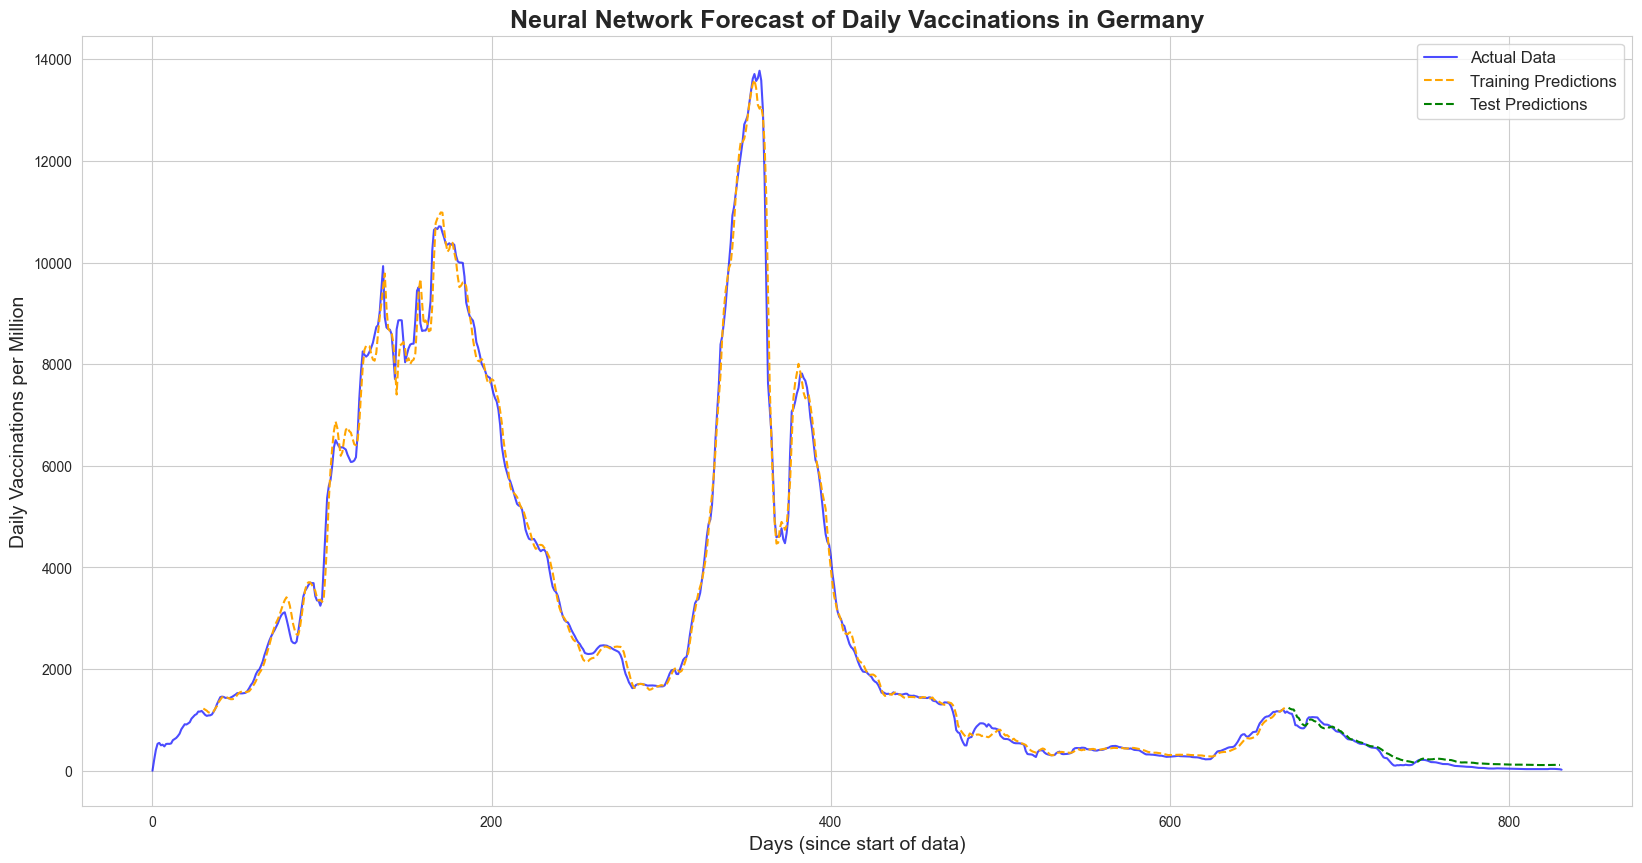

In [22]:
# Create the plot
plt.figure(figsize=(20, 10))
plt.plot(original_data, label='Actual Data', color='blue', alpha=0.7)
plt.plot(train_plot, label='Training Predictions', color='orange', linestyle='--')
plt.plot(test_plot, label='Test Predictions', color='green', linestyle='--')
plt.title(f"Neural Network Forecast of Daily Vaccinations in {country}", fontsize=18, weight='bold')
plt.xlabel('Days (since start of data)', fontsize=14)
plt.ylabel('Daily Vaccinations per Million', fontsize=14)
plt.legend(fontsize=12)
plt.show()

# Observations & Conclusion

**1. Model Performance:**
The plot shows that the neural network (green dashed line) learned the general pattern of the actual data (blue line) very well. It successfully captured the major surges and declines in Germany's vaccination rate. The `Test RMSE` value gives us a measure of the average error in its predictions.

**2. Insights:**
* **Pattern Recognition:** The model's ability to follow the trend (even on the unseen test data) shows that a country's vaccination history is a very strong predictor of its immediate future.
* **Non-Linearity:** This task is not a simple straight line. The model had to learn complex, non-linear patterns (the "waves" of vaccination). A simple linear regression would have failed, but the deep learning model was able to adapt.

**3. Conclusion:**
This demonstrates that deep learning (specifically, a neural network) is a powerful tool for this dataset. We can successfully forecast vaccination pace, which would be incredibly valuable for governments and health organizations for resource allocation, policy planning, and managing public expectations.